# Decision Tree

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import os
if os.getcwd().endswith('notebooks'):
    os.chdir('../')
from src.decision_tree import DecisionTreeClassification, Node

Unlike the models introduced previously, decision trees are can fit non-linear relationships in the data. They can be used for both classification and regression tasks, and even with multioutputs. </br>
In a decision tree, the data is split again and again for certain, values of the featuers

# Datasets

We start with this simple synthetic dataset to reduce the complexity while working through the implementation of the decision tree algorithm.

In [3]:
age = [20, 25, 35, 40, 50] 
classe = [0, 0,  1,  1,  0] 
salary = [1500, 1800, 2500, 3200, 4000]

synth_df = pd.DataFrame({"age":age, "classe":classe, "salary":salary})
display(synth_df)

,age,classe,salary
0,20,0,1500
1,25,0,1800
2,35,1,2500
3,40,1,3200
4,50,0,4000


Then we will move on to the iris dataset. This famous dataset contains 150 flower samples from three different species (target classes) and each flower is described by four numerical values (features).

In [5]:
from sklearn.datasets import load_iris
from sklearn.tree import export_graphviz


iris = load_iris()

df = pd.DataFrame(iris.data,columns=iris.feature_names)

df["target"] = iris.target
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


# Training (Growing a tree)

I found decision trees to be more intuitive, at least at a surface level, than the models we already covered so far. However, once you explore them in greater depth I found them more complex and difficult to understand.
Fortunately they are well covered in *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. I also really recommend *The elements of statistical learning: Data mining, inference, and prediction* by Hastie, Tibshirani, & Friedman. 
</br>
</br>
</br>
A decision tree is composed of 3 different types of nodes:
- The root node, which is the node at the top.
- A decision node, which represents a choice we make.
- A leaf node, which indicates a final outcome.

Training a decision tree means figuring out how it should be assembled from the root to the leaves.
</br>

## Classification And Regression Trees (CART)

CART builds binary decision trees, meaning that each decision node splits the data into exactly two branches. </br>
Imagine the feature space as a field containing all the data points. At each decision node, the algorithm cuts this field into two parts. Each cut is based on one feature $k$ and a threshold $t$. 
</br>
The goal is to best separate data in term of class. The process is repeated recursively until a stopping criterion is reached and the leaf nodes produce the final predictions.
</br>
 This graph illustrates how succesive cuts divide the feature space into smaller regions $R$.

![description](../images/cart2d.png)

To choose $k$ and $t_k$, the aglorithm has to search the pair ($k$, $t_k$) that produces the purest subset (weighted by their size).

Purity means that the classes are not mixed within a node of a decision tree. We can measure it with Gini impurity:

$$
G_i = 1 - \sum_{k=1}^{n} p_{i,k}^{2}
$$

Where:

- $G_i$: impurity of node $i$
- $n$: number of possible classes
- $p_{i,k}$: proportion of examples belonging to class $k$ in node $i$

We can compute the gini impurety for a column as below. In our case, the classes are really mixed up.

In [44]:
def gini(y: np.ndarray):
    values, counts = np.unique(y, return_counts=True)
    proportions = counts / len(y)
    return 1 - np.sum(proportions ** 2)

gini(df['petal length (cm)'])

np.float64(0.9612444444444445)

The cost function for the CART algorithm is:

$$
J(k, t_k)
=
\frac{m_{\text{left}}}{m} G_{\text{left}}
+
\frac{m_{\text{right}}}{m} G_{\text{right}}

$$

Where: 
- $G_{\text{left/right}} \text{ measures the impurity of the left/right subset,}$
- $m_{\text{left/right}} \text{ is the number of instances in the left/right subset.}$

In a nutshell, an instance is a row of the dataset.

$$

$$

# Implementation

The complete implementation is available in in `src/decision_tree.py`.
</br>
This section presents the main composents required to understand how the classifier is built. The impletementation is divided in two classes:
- Node, that stores the information of a node.
- DecisionTree, where everything happens. It builds the tree and makes the predictions

## Node

This class can represent both a decision node, which tests a feature and a threshold or a leaf node, which stores a final prediction.

In [ ]:
class Node:
    
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):

        # decision node
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right

        # leaf
        self.value = value

We can know if a node is a leaf using:

In [11]:
node = Node(value=1)

node.value is not None

True

## DecisionTree

The DecisionTree class contains:
- The hyperparameters of the model
- The root node
- The methods used to find splits
- The recursive tree logic
- The prediction methods

In [ ]:
class DecisionTreeClassification:

    def __init__(self, max_depth = 5, min_samples_split = 2):
        self.max_depth = max_depth # limits the depth of the tree
        self.min_samples_split = min_samples_split # prevents nodes with too few samples from being split
        self.root = None  # stores the first node of the tree

Before building the tree recursively, the algorithm must determine the best way to split the samples at the current node. It evaluates several candidate thresholds across all available features and compares how well each split separates the classes. This selection process follows a simple pipeline: measure the impurity of the resulting subsets, compute the cost of each candidate threshold, identify the best threshold for each feature, and finally select the best overall split for the node. 
</br>
</br>
MakeNode() uses the best split to divide the data in two groups. It then repeats the same process on each group until a leaf is created.

In [ ]:
def MakeNode(self, X, y, depth = 0):

    X = np.array(X)
    y = np.array(y)

    if (
        len(np.unique(y)) == 1 # nothing to divide
    or depth >= self.max_depth # stop at desired depth
    or len(y) < self.min_samples_split # min sample number
    ):
        value = self.MostCommonClass(y)

        return Node(value=value)
    
    feature, treshold, cost = self.FindBestSplit(X, y)
    feature_values = X[:, feature]

    left_mask = feature_values <= treshold
    right_mask = feature_values > treshold

    left_node = self.MakeNode(X = X[left_mask], y = y[left_mask], depth = depth + 1)
    right_node = self.MakeNode(X = X[right_mask], y = y[right_mask], depth = depth + 1)
    
    return Node(feature, threshold=treshold, left=left_node, right=right_node)

## Trying it

In [4]:
X = synth_df[["age", "salary"]].to_numpy()
y = synth_df["classe"].to_numpy()

model = DecisionTreeClassification()
model.fit(X=X, y=y).predict([37, 2000])

array([1])

# Hypotheses of the decision tree

Linear models are parametric models meaning the number of parameters is fix. This reduces the degree of freedom, thus reducing the risk of overfitting but increasing the risk of underfitting. 
</br>
Decisions trees are nonparametric models, meaning the models can evolve closer to the data. 
</br>
To avoid overfitting, we need to limit the degree of freedom of the algorithm, which is also called regularization. To do so, we use hyperparameters such as:
- Maximal depth: limits how deep the tree can grow. Reducing this hyperparameters will prevent the algorithm from making too many successive splits.
- Minimum sample size split: sets the minimum sample size required to split a node. Increasing it prevents the model from splitting small subsets.
- Minimum sample size for a leaf: sets the number of samples required in each leaf. Increasing it prevents the model from making very small leaves.
- Maximum number of leaves: limits the number of leaf nodes in the tree. Reducing it prevents the model from growing too many branches.
- Maximum number of features: limits the number of features evaluated. Reducing it makes the search more restricted.

Below is a visualization of how changing the maximal depth affects the fit.

In [17]:
feature_columns = [
    "petal length (cm)",
    "petal width (cm)",
]

X = df[feature_columns].to_numpy(dtype=float)
y = df["target"].to_numpy()


tree_unrestricted = DecisionTreeClassification(max_depth=5)
tree_unrestricted.fit(X=X, y=y)

tree_regularized = DecisionTreeClassification(max_depth=2)
tree_regularized.fit(X=X, y=y)

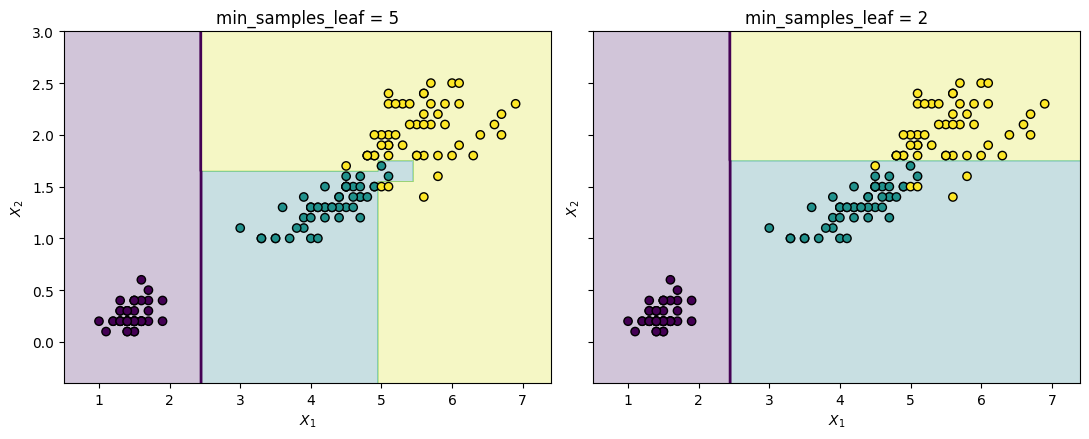

In [ ]:
def plot_decision_regions(model, X, y, ax, title):
    margin = 0.5

    # first feature
    x1_min = X[:, 0].min() - margin
    x1_max = X[:, 0].max() + margin

    # second feature
    x2_min = X[:, 1].min() - margin
    x2_max = X[:, 1].max() + margin

    # dense grid over the feature space
    x1_values = np.linspace(x1_min, x1_max, 400)
    x2_values = np.linspace(x2_min, x2_max, 400)

    X1, X2 = np.meshgrid(x1_values, x2_values)

    # convert each point of the grid into an observation
    grid_points = np.column_stack([X1.ravel(),X2.ravel()])

    # predict the class of every grid point
    Z = model.predict(grid_points)
    Z = Z.reshape(X1.shape)

    # background decision regions
    ax.contourf(X1,X2,Z,alpha=0.25)

    # decision boundaries
    ax.contour(X1,X2,Z,levels=[0.5],linewidths=2)

    # training observations
    ax.scatter(X[:, 0],X[:, 1],c=y,edgecolors="black")

    ax.set_xlabel("$X_1$")
    ax.set_ylabel("$X_2$")
    ax.set_title(title)


fig, axes = plt.subplots(1,2,figsize=(11, 4.5),sharex=True,sharey=True)

plot_decision_regions(tree_unrestricted,X,y,axes[0],"min_samples_leaf = 5")

plot_decision_regions(tree_regularized,X,y,axes[1],"min_samples_leaf = 2")

plt.tight_layout()
plt.show()

# ben

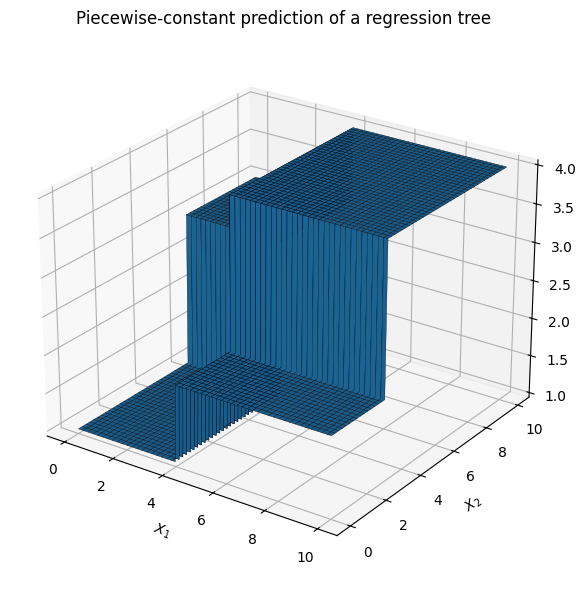

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Grid over the feature space
x1 = np.linspace(0, 10, 200)
x2 = np.linspace(0, 10, 200)
X1, X2 = np.meshgrid(x1, x2)

# Piecewise-constant prediction produced by a tree
Z = np.zeros_like(X1)

Z[(X1 <= 4) & (X2 <= 6)] = 1
Z[(X1 <= 4) & (X2 > 6)] = 3
Z[(X1 > 4) & (X2 <= 3)] = 2
Z[(X1 > 4) & (X2 > 3)] = 4

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X1,
    X2,
    Z,
    edgecolor="black",
    linewidth=0.25,
    antialiased=True,
)

ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.set_zlabel("Prediction")
ax.set_title("Piecewise-constant prediction of a regression tree")

ax.view_init(elev=25, azim=-55)

plt.tight_layout()
plt.savefig("regression_tree_partition.svg", bbox_inches="tight")
plt.show()